In [43]:
import pandas as pd
import numpy as np

In [44]:
df = pd.read_csv("credit_card_transactions.csv", nrows=200000)

In [70]:
chunk_size = 100000

chunks = pd.read_csv("credit_card_transactions.csv", chunksize=chunk_size)
df = pd.concat(chunks, ignore_index=True)

In [71]:
df.head(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,-75.2045,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0,17972.0
6,6,2019-01-01 00:04:42,30074693890476,fraud_Rowe-Vandervort,grocery_net,44.54,Kelsey,Richards,F,889 Sarah Station Suite 624,...,-100.9893,2691,Arboriculturist,1993-08-16,83ec1cc84142af6e2acf10c44949e720,1325376282,37.162705,-100.153370,0,NaN
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,-78.6003,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0,22644.0
8,8,2019-01-01 00:05:18,4922710831011201,fraud_Herzog Ltd,misc_pos,4.27,Heather,Chase,F,6888 Hicks Stream Suite 954,...,-79.6607,1472,Public affairs consultant,1941-03-07,fc28024ce480f8ef21a32d64c93a29f5,1325376318,40.351813,-79.958146,0,15236.0
9,9,2019-01-01 00:06:01,2720830304681674,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,...,-87.3490,151785,Pathologist,1974-03-28,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0,42442.0


In [72]:
df.shape

(1296675, 24)

In [73]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [75]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.100702e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,4.682575e+04
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,2.583400e+04
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,1.001000e+03
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,2.511400e+04
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,4.586000e+04
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,6.831900e+04
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,9.940300e+04


In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
type('trans_date_trans_time')

str

In [78]:
df.loc[:, 'trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [79]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

In [81]:
df = df.drop(columns=['Unnamed: 0', 'first', 'last', 'street', 'trans_num', 'cc_num', 'zip', 'merch_zipcode', 'lat', 'long', 'unix_time', 'merch_lat', 'merch_long'])

In [82]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender',
       'city', 'state', 'city_pop', 'job', 'dob', 'is_fraud', 'distance_km'],
      dtype='object')

In [83]:
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [84]:
df['fraud_label'] = df['is_fraud'].map({0: 'No', 1: 'Yes'})

In [85]:
df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time'],
    errors='coerce'
)

In [86]:
df['trans_date_trans_time'].dtype

dtype('<M8[ns]')

In [87]:
 #Feature Engineering
df['month'] = df['trans_date_trans_time'].dt.month
df['day'] = df['trans_date_trans_time'].dt.day
df['year'] = df['trans_date_trans_time'].dt.year

In [88]:
df['trans_date_trans_time'].isnull().sum()

np.int64(0)

In [89]:
df.head()

,trans_date_trans_time,merchant,category,amt,gender,city,state,city_pop,job,dob,is_fraud,distance_km,fraud_label,month,day,year
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,3495,"Psychologist, counselling",1988-03-09,0,78.597568,No,1,1,2019
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,149,Special educational needs teacher,1978-06-21,0,30.212176,No,1,1,2019
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,4154,Nature conservation officer,1962-01-19,0,108.206083,No,1,1,2019
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,1939,Patent attorney,1967-01-12,0,95.673231,No,1,1,2019
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,99,Dance movement psychotherapist,1986-03-28,0,77.556744,No,1,1,2019


In [90]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender',
       'city', 'state', 'city_pop', 'job', 'dob', 'is_fraud', 'distance_km',
       'fraud_label', 'month', 'day', 'year'],
      dtype='object')

In [91]:
#Remove invalid values
df = df[df['amt'] > 0]

In [92]:
#Clean text values
df['category'] = df['category'].str.lower().str.strip()
df['merchant'] = df['merchant'].str.lower().str.strip()

In [93]:
#Extracting Age from Date of birth
df['dob'] = pd.to_datetime(df['dob'])

df['age'] = df['year'] - df['dob'].dt.year

In [94]:
#Removing DOB column
df = df.drop(columns=['dob'])

In [95]:
#Create hour column
df['hour'] = df['trans_date_trans_time'].dt.hour

In [96]:
df.head()

,trans_date_trans_time,merchant,category,amt,gender,city,state,city_pop,job,is_fraud,distance_km,fraud_label,month,day,year,age,hour
0,2019-01-01 00:00:18,"fraud_rippin, kub and mann",misc_net,4.97,F,Moravian Falls,NC,3495,"Psychologist, counselling",0,78.597568,No,1,1,2019,31,0
1,2019-01-01 00:00:44,"fraud_heller, gutmann and zieme",grocery_pos,107.23,F,Orient,WA,149,Special educational needs teacher,0,30.212176,No,1,1,2019,41,0
2,2019-01-01 00:00:51,fraud_lind-buckridge,entertainment,220.11,M,Malad City,ID,4154,Nature conservation officer,0,108.206083,No,1,1,2019,57,0
3,2019-01-01 00:01:16,"fraud_kutch, hermiston and farrell",gas_transport,45.00,M,Boulder,MT,1939,Patent attorney,0,95.673231,No,1,1,2019,52,0
4,2019-01-01 00:03:06,fraud_keeling-crist,misc_pos,41.96,M,Doe Hill,VA,99,Dance movement psychotherapist,0,77.556744,No,1,1,2019,33,0


In [97]:
df = df.rename(columns={'amt': 'amount'})

In [98]:
df = df.rename(columns={'trans_date_trans_time': 'transaction_date_time'})

In [99]:
df.columns

Index(['transaction_date_time', 'merchant', 'category', 'amount', 'gender',
       'city', 'state', 'city_pop', 'job', 'is_fraud', 'distance_km',
       'fraud_label', 'month', 'day', 'year', 'age', 'hour'],
      dtype='object')

Exploratory Data Analysis

1. Fraud Distribution

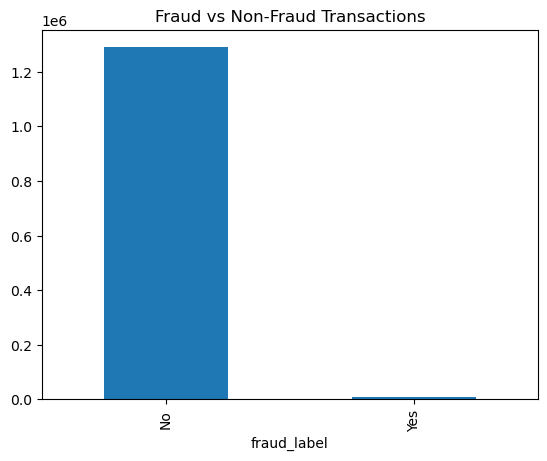

In [100]:
df['fraud_label'].value_counts()
df['fraud_label'].value_counts(normalize=True) * 100

import matplotlib.pyplot as plt

df['fraud_label'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

2. Transaction Amount Analysis

In [101]:
df['amount'].describe()

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amount, dtype: float64

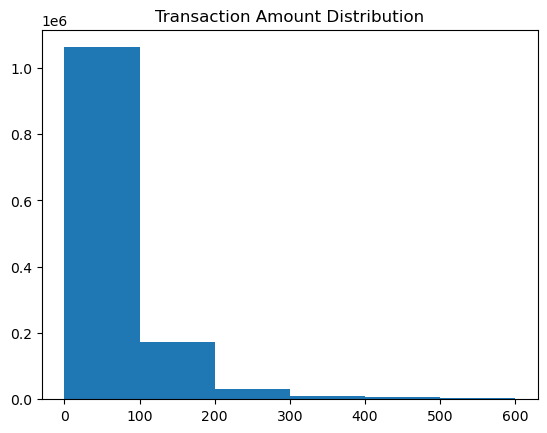

In [102]:
plt.figure()
#df['amount'].hist(bins=5)
plt.hist(df['amount'], bins=[0, 100, 200, 300, 400, 500, 600])
plt.title("Transaction Amount Distribution")
plt.show()

3. Fraud vs Amount

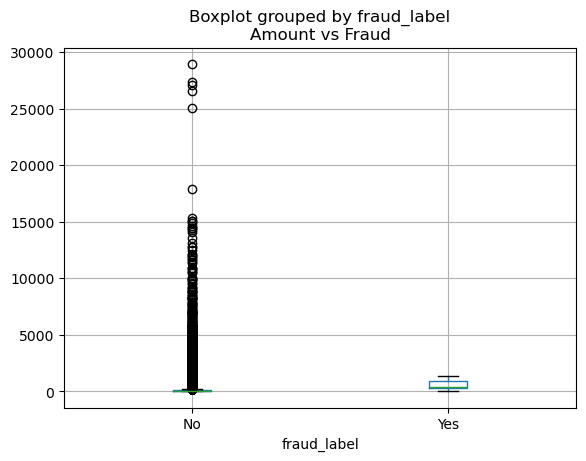

In [103]:
df.groupby('fraud_label')['amount'].mean()

df.boxplot(column='amount', by='fraud_label')
plt.title("Amount vs Fraud")
plt.show()

4. Category Analysis

In [104]:
category_spend = df.groupby('category')['amount'].sum().sort_values(ascending=False)
category_spend.head(10)

category
grocery_pos      14460822.38
shopping_pos      9307993.61
shopping_net      8625149.68
gas_transport     8351732.29
home              7173928.11
kids_pets         6503680.16
entertainment     6036678.56
misc_net          5117709.26
misc_pos          5009582.50
food_dining       4672459.44
Name: amount, dtype: float64

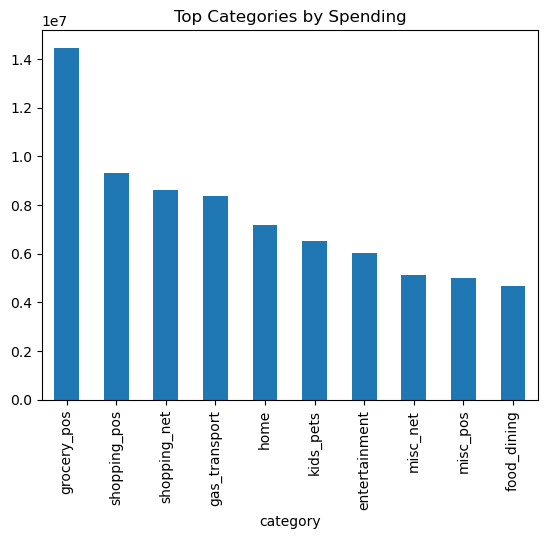

In [105]:
category_spend.head(10).plot(kind='bar')
plt.title("Top Categories by Spending")
plt.show()

5. Fraud by Category

In [106]:
fraud_category = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
fraud_category.head(10)

category
shopping_net     0.017561
misc_net         0.014458
grocery_pos      0.014098
shopping_pos     0.007225
gas_transport    0.004694
misc_pos         0.003139
grocery_net      0.002948
travel           0.002864
entertainment    0.002478
personal_care    0.002424
Name: is_fraud, dtype: float64

6. Monthly Spending Trend

In [107]:
monthly_spend = df.groupby('month')['amount'].sum()
monthly_spend

month
1      7422814.52
2      6974606.28
3     10190002.48
4      9452834.36
5     10304940.14
6     10143382.17
7      6044026.74
8      6047288.65
9      4949834.42
10     4851267.37
11     4923252.59
12     9918179.18
Name: amount, dtype: float64

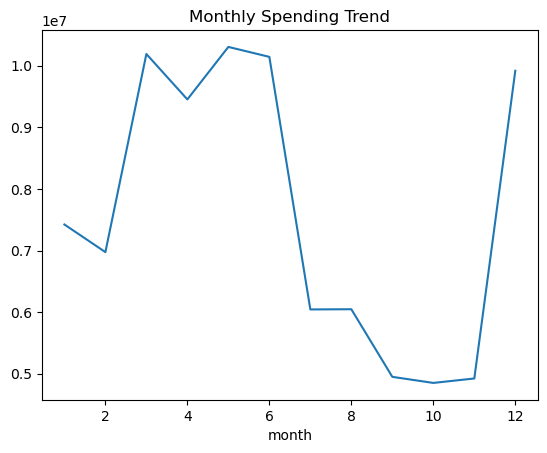

In [108]:
monthly_spend.plot()
plt.title("Monthly Spending Trend")
plt.show()

7. Hourly Spending Trend

In [109]:
hourly_txn = df.groupby('hour')['amount'].count()
hourly_txn

hour
0     42502
1     42869
2     42656
3     42769
4     41863
5     42171
6     42300
7     42203
8     42505
9     42185
10    42271
11    42082
12    65257
13    65314
14    64885
15    65391
16    65726
17    65450
18    66051
19    65508
20    65098
21    65533
22    66982
23    67104
Name: amount, dtype: int64

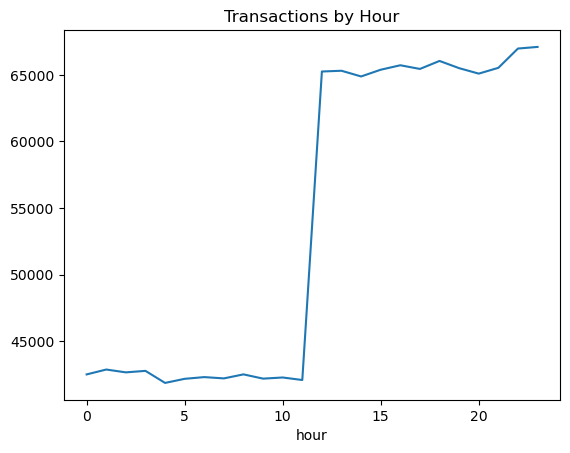

In [110]:
hourly_txn.plot()
plt.title("Transactions by Hour")
plt.show()

8. Fraud by Hour

In [111]:
fraud_hour = df.groupby('hour')['amount'].mean()
fraud_hour

hour
0     79.149321
1     79.640242
2     80.045273
3     79.318226
4     76.094214
5     75.957616
6     75.693290
7     75.893703
8     76.131963
9     75.164735
10    75.413802
11    76.697639
12    61.373212
13    63.782815
14    63.353854
15    63.013528
16    63.881087
17    63.475335
18    62.867608
19    63.111108
20    63.466081
21    63.050888
22    80.741360
23    79.103247
Name: amount, dtype: float64

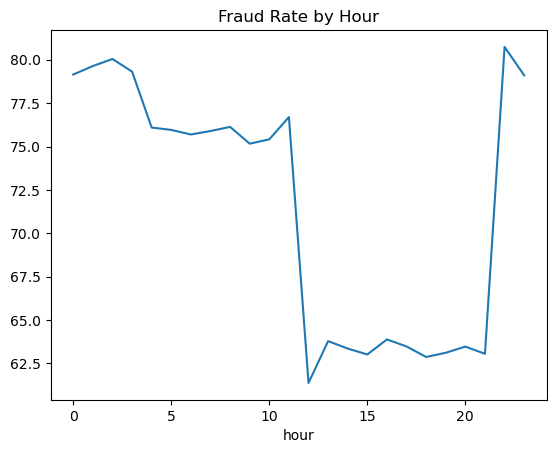

In [112]:
fraud_hour.plot()
plt.title("Fraud Rate by Hour")
plt.show()

9. Customer Insights

In [113]:
df.groupby('gender')['amount'].mean()

gender
F    70.200324
M    70.533350
Name: amount, dtype: float64

In [114]:
df['job'].value_counts().head(10)

job
Film/video editor             9779
Exhibition designer           9199
Naval architect               8684
Surveyor, land/geomatics      8680
Materials engineer            8270
Designer, ceramics/pottery    8225
Systems developer             7700
IT trainer                    7679
Financial adviser             7659
Environmental consultant      7547
Name: count, dtype: int64

10. Location Analysis

In [115]:
df['state'].value_counts().head(10)

state
TX    94876
NY    83501
PA    79847
CA    56360
OH    46480
MI    46154
IL    43252
FL    42671
AL    40989
MO    38403
Name: count, dtype: int64

In [116]:
df.groupby('state')['amount'].sum().sort_values(ascending=False).head(10)

state
TX    6800917.53
NY    6006499.03
PA    5771009.53
CA    4138078.51
OH    3396146.66
MI    3282724.96
FL    3155191.63
IL    3011891.30
AL    2682717.10
MO    2637453.06
Name: amount, dtype: float64

END OF EDA

In [117]:
df.to_csv(
    r"D:\Personal Projects\Credit Card Transactions Analysis\cleaned_creditcard_dataset.csv",
    index=False,
    encoding='utf-8'
)